# Information regarding Dataset

Link: https://bigearth.net

Paper: https://arxiv.org/abs/2407.03653
```
K. Clasen, L. Hackel, T. Burgert, G. Sumbul, B. Demir, V. Markl, " reBEN: Refined BigEarthNet Dataset for Remote Sensing Image Analysis ", arXiv preprint arXiv:2407.03653, 2024 .
```

## Dataset Freatures
- 312 Sentinel-1 scenes acquired between June 2017 and May 2018 that jointly cover the area of all original 115 Sentinel-2 tiles with close temporal proximity were selected and processed. BigEarthNet-S1 consists of 549,488 preprocessed Sentinel-1 image patches – one for each Sentinel-2 patch.
- 19 classes

## Klassen (19 + 1 unlabeled)
* "Urban fabric": 1,
* "Industrial or commercial units": 2,
* "Arable land": 3,
* "Permanent crops": 4,
* "Pastures": 5,
* "Complex cultivation patterns": 6,
* "Land principally occupied by agriculture, with significant areas of natural vegetation" : 7,
* "Agro-forestry areas": 8,
* "Broad-leaved forest": 9,
* "Coniferous forest": 10,
* "Mixed forest": 11,
* "Natural grassland and sparsely vegetated areas": 12,
* "Moors, heathland and sclerophyllous vegetation": 13,
* "Transitional woodland, shrub": 14,
* "Beaches, dunes, sands": 15,
* "Inland wetlands": 16,
* "Coastal wetlands": 17,
* "Inland waters": 18,
* "Marine waters": 19,
* "Unlabeled": 20,

# Setup (Imports, Parameters)

In [1]:
# Standard Libraries
import os
import random
import pickle
from glob import glob
from pathlib import Path

# Image Processing
import cv2
from PIL import Image
import rasterio
# from patchify import patchify

# Plotting
import matplotlib.pyplot as plt
from matplotlib import pyplot as plt

# Machine Learning and Deep Learning
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.amp import GradScaler, autocast
from torchvision.transforms import Compose, Resize, ToTensor
import albumentations as A
import segmentation_models_pytorch as smp
from segmentation_models_pytorch import Unet
from segmentation_models_pytorch.losses import DiceLoss, SoftBCEWithLogitsLoss, JaccardLoss, FocalLoss
from sklearn.model_selection import train_test_split
from reben_publication.BigEarthNetv2_0_ImageClassifier import BigEarthNetv2_0_ImageClassifier

# Data Handling
import numpy as np
import lmdb
from safetensors.numpy import load
# import h5py

# Progress Bar
from tqdm import tqdm

# TensorBoard
from torch.utils.tensorboard import SummaryWriter

# Custom Library
import ActivationPrototypes_SARSeg.thesis_utils as utils
from ActivationPrototypes_SARSeg.thesis_utils import *

c:\Users\Jean\anaconda3\envs\ActivationPrototypes_SARSeg\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-01-29 12:47:51.661 | INFO     | ActivationPrototypes_SARSeg.config:<module>:11 - PROJ_ROOT path is: F:\Thesis\ActivationPrototypes_SARSeg


## Parameters

In [2]:
lmdb_path = "F:\\Thesis\\Datasets\\Big Earth\\Encoded-BigEarthNet"
parquet_path = "F:\\Thesis\Datasets\\Big Earth\\metadata.parquet"

want_to_train = False # Set this flag to True if you want to train the model

seed=24   # Fix the seed for reproducibility
batch_size= 16
NUM_CLASSES = 20 # 19 classes + 1 unlabeled
n_classes = num_class = NUM_CLASSES

BACKBONE = 'resnet50'
WEIGHTS = None

IMG_HEIGHT = 120
IMG_WIDTH  = 120
IMG_CHANNELS = 2

In [3]:
# Calculate and Save Matches
# matches = match_keys_dynamic(lmdb_path)

# Save the matches
# with open("matches/matches.pkl", "wb") as f:
#     pickle.dump(matches, f)

In [4]:
# Matches
with open("..\data\matches\matches.pkl", "rb") as f:
    matches = pickle.load(f)

print(f"Loaded {len(matches)} matches:")
for image_key, reference_key in matches[:5]:  # Print first 5 matches
    print(f"Image: {image_key}, Reference: {reference_key}")

Loaded 199361 matches:
Image: S1A_IW_GRDH_1SDV_20170718T063826_29UPB_14_65, Reference: S2B_MSIL2A_20170718T115359_N9999_R023_T29UPB_14_65_reference_map
Image: S1B_IW_GRDH_1SDV_20180225T063817_29UPU_46_24, Reference: S2B_MSIL2A_20180421T114349_N9999_R123_T29UPU_46_24_reference_map
Image: S1B_IW_GRDH_1SDV_20180517T154802_35VNJ_70_34, Reference: S2B_MSIL2A_20180515T094029_N9999_R036_T35VNJ_70_34_reference_map
Image: S1B_IW_GRDH_1SDV_20171101T153951_35VNJ_18_10, Reference: S2B_MSIL2A_20180515T094029_N9999_R036_T35VNJ_18_10_reference_map
Image: S1B_IW_GRDH_1SDV_20180130T162407_34TEP_77_60, Reference: S2B_MSIL2A_20180502T093039_N9999_R136_T34TEP_77_60_reference_map


In [5]:
matches_shorter = matches[:1000]  # Use only the first 10 matches for demonstration

# Exploration

## Segmentation Mask - Visualization from File

[[313 313 313 ... 312 312 312]
 [313 313 313 ... 312 312 312]
 [313 313 313 ... 312 312 312]
 ...
 [312 312 312 ... 311 311 311]
 [312 312 312 ... 311 311 311]
 [312 312 312 ... 311 311 311]]
[[-13.83298  -13.640013 -13.895322 ... -18.065521 -15.464274 -12.377541]
 [-15.266037 -15.864015 -16.714687 ... -13.726348 -14.961382 -14.388217]
 [-12.4349   -13.648561 -15.688725 ... -11.050258 -12.05038  -14.296645]
 ...
 [-16.013206 -17.524551 -15.946453 ... -12.125894 -12.066266 -14.25565 ]
 [-14.748832 -15.589849 -14.51783  ... -15.835401 -14.847834 -14.858087]
 [-13.872749 -14.231482 -13.465116 ... -14.311543 -13.849222 -14.204564]]


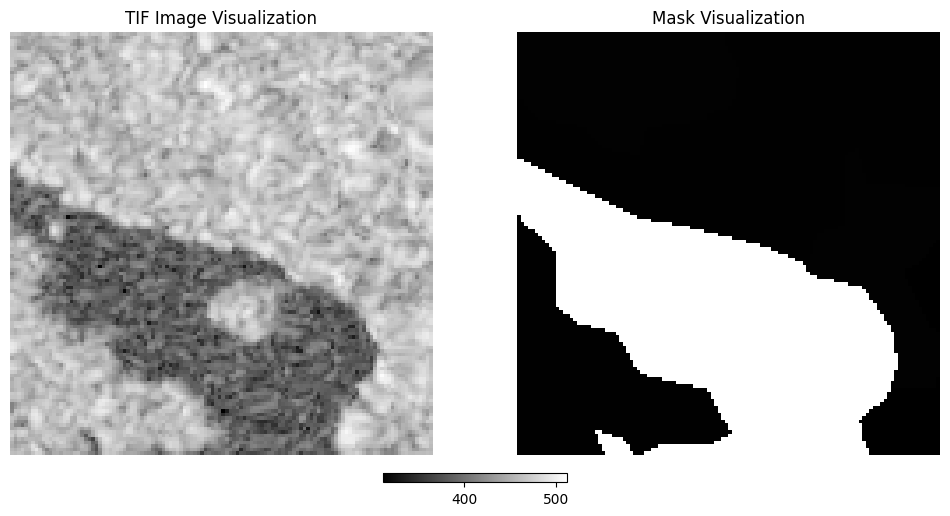

In [6]:
# Path to the .tif file
example_mask_path = "F:\\Thesis\\Datasets\\Big Earth\\Reference_Maps\\S2A_MSIL2A_20170701T093031_N9999_R136_T35VPK\\S2A_MSIL2A_20170701T093031_N9999_R136_T35VPK_57_02\\S2A_MSIL2A_20170701T093031_N9999_R136_T35VPK_57_02_reference_map.tif"
image_path = "F:\\Thesis\\Datasets\\Big Earth\\BigEarthNet-S1\\BigEarthNet-S1\\S1A_IW_GRDH_1SDV_20170630T152421\\S1A_IW_GRDH_1SDV_20170630T152421_35VPK_57_2\\S1A_IW_GRDH_1SDV_20170630T152421_35VPK_57_2_VH.tif"

# Open the .tif file
with rasterio.open(example_mask_path) as src:
    # Read the image data into an array
    mask_array = src.read(1)  # Read the first band

with rasterio.open(image_path) as src:
    # Read the image data into an array
    image_array = src.read(1)

# Print the array
print(mask_array)
print(image_array)

# Visualize the image and mask
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Display the image
axes[0].imshow(image_array, cmap='gray')
axes[0].set_title('TIF Image Visualization')
axes[0].axis('off')

# Display the mask
axes[1].imshow(mask_array, cmap='gray')
axes[1].set_title('Mask Visualization')
axes[1].axis('off')

plt.colorbar(axes[1].imshow(mask_array, cmap='gray'), ax=axes, orientation='horizontal', fraction=0.02, pad=0.04)
plt.show()

## Class Distribution in Masks - No need to run

In [7]:
# iterate over all matches and count pixels

# Count unique pixel values in the mask
total_pixel_counts = {}

# Print the pixel counts
env = lmdb.open(lmdb_path, readonly=True, lock = False)
for image_key, reference_key in matches:
    with env.begin() as txn:
        reference_safetensor_dict = load(txn.get(reference_key.encode()))

    mask = reference_safetensor_dict["Data"]
    unique, counts = np.unique(mask, return_counts=True)
    for value, count in zip(unique, counts):
        if value not in total_pixel_counts:
            total_pixel_counts[value] = 0
        total_pixel_counts[value] += count


In [8]:
# Print the pixel counts
# Sort the pixel counts by value
total_pixel_counts = dict(sorted(total_pixel_counts.items()))
for value, count in total_pixel_counts.items():
    print(f"Value {value}: {count} pixels")

print(len(total_pixel_counts))

Value 111: 1887229 pixels
Value 112: 69643594 pixels
Value 121: 9721228 pixels
Value 122: 1068284 pixels
Value 123: 111779 pixels
Value 124: 247727 pixels
Value 131: 1447378 pixels
Value 132: 246139 pixels
Value 133: 349289 pixels
Value 141: 696728 pixels
Value 142: 1574232 pixels
Value 211: 398505825 pixels
Value 212: 11656883 pixels
Value 213: 2714239 pixels
Value 221: 9950108 pixels
Value 222: 4346588 pixels
Value 223: 11720168 pixels
Value 231: 180314255 pixels
Value 241: 6239440 pixels
Value 242: 122708509 pixels
Value 243: 138648712 pixels
Value 244: 41850914 pixels
Value 311: 243590946 pixels
Value 312: 451626072 pixels
Value 313: 383249947 pixels
Value 321: 11600471 pixels
Value 322: 6290759 pixels
Value 323: 10293058 pixels
Value 324: 170259189 pixels
Value 331: 883238 pixels
Value 332: 947947 pixels
Value 333: 1953359 pixels
Value 334: 89408 pixels
Value 411: 4520392 pixels
Value 412: 35853503 pixels
Value 421: 1247719 pixels
Value 422: 189119 pixels
Value 423: 334148 pixels


Urban fabric: 71530823 pixels
Industrial or commercial units: 9721228 pixels
Unlabeled: 7842189 pixels
Arable land: 412876947 pixels
Permanent crops: 32256304 pixels
Pastures: 180314255 pixels
Complex cultivation patterns: 122708509 pixels
Land principally occupied by agriculture, with significant areas of natural vegetation: 138648712 pixels
Agro-forestry areas: 41850914 pixels
Broad-leaved forest: 243590946 pixels
Coniferous forest: 451626072 pixels
Mixed forest: 383249947 pixels
Natural grassland and sparsely vegetated areas: 13553830 pixels
Moors, heathland and sclerophyllous vegetation: 16583817 pixels
Transitional woodland, shrub: 170259189 pixels
Beaches, dunes, sands: 883238 pixels
Inland wetlands: 40373895 pixels
Coastal wetlands: 1436838 pixels
Inland waters: 144814446 pixels
Marine waters: 386676301 pixels


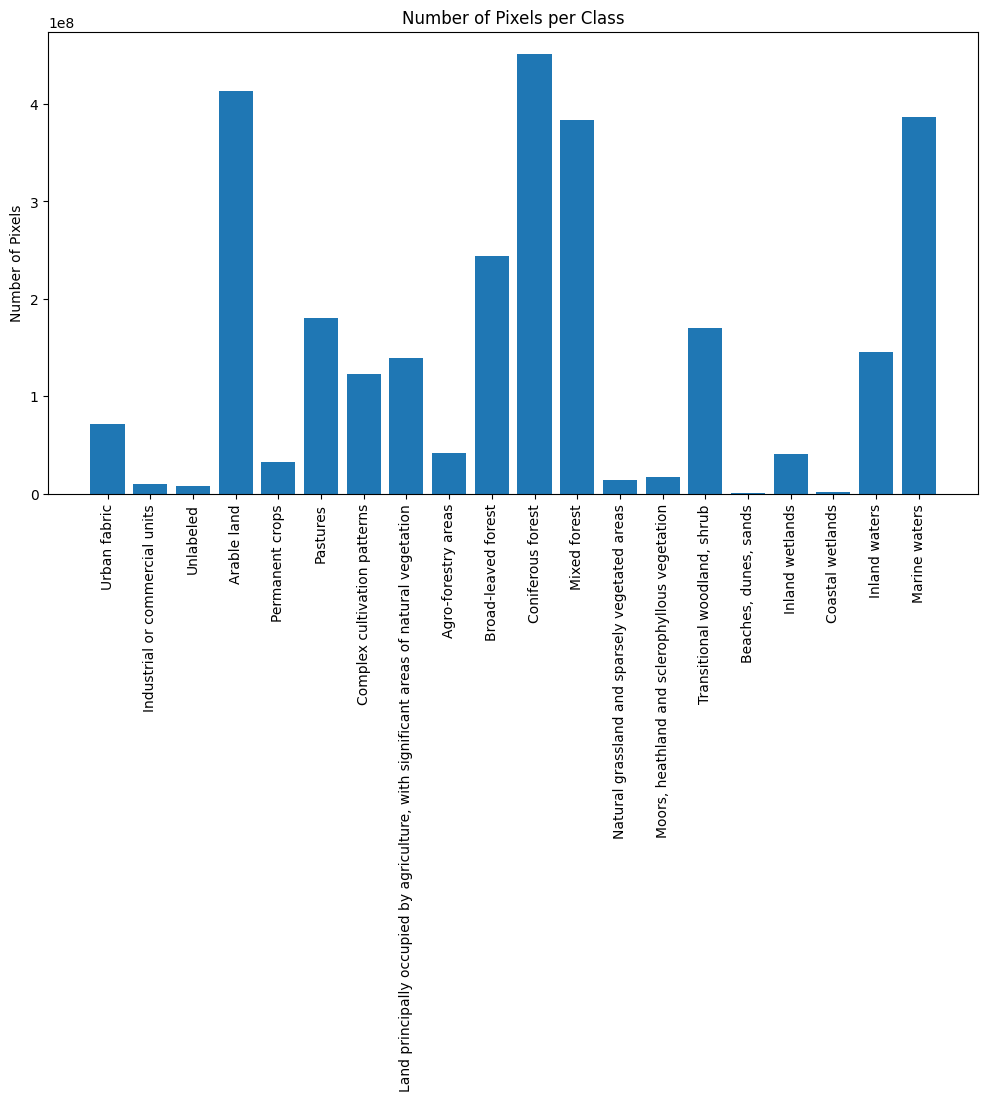

In [9]:
# Count the number of pixels per class
class_pixel_counts = {class_name: 0 for class_name in pixel_value_to_class_name.values()}
for value, count in total_pixel_counts.items():
    class_name = pixel_value_to_class_name.get(value, "Unknown")
    class_pixel_counts[class_name] += count

# Print the pixel counts per class
for class_name, count in class_pixel_counts.items():
    print(f"{class_name}: {count} pixels")

# Visualize the pixel counts per class
plt.figure(figsize=(12, 6))
plt.bar(class_pixel_counts.keys(), class_pixel_counts.values())
plt.xticks(rotation=90)
plt.ylabel("Number of Pixels")
plt.title("Number of Pixels per Class")
plt.show()


In [10]:
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"Device: {torch.cuda.get_device_name(0)}")
print(f"PyTorch Version: {torch.__version__}")
# Check if GPU is available and set the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

CUDA Available: True
Device: NVIDIA GeForce RTX 3080 Ti
PyTorch Version: 2.5.1+cu118
cuda


# Model, Splits, DataSets and DataLoader

In [11]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the model
model = create_base_model().to(device)

print(model)

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(2, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
      

In [12]:
# Define the transformations
transformx = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
],is_check_shapes=False)

# Parquet file with metadata for Big Earth dataset
train_matches, val_matches, test_matches = match_keys(parquet_path)

print(f"Train size: {len(train_matches)}, Val size: {len(val_matches)}, Test size: {len(test_matches)}")

# Create datasets
train_dataset = SARSegmentationDataset(lmdb_path, train_matches, transform=transformx)
val_dataset = SARSegmentationDataset(lmdb_path, val_matches, transform=None)
test_dataset = SARSegmentationDataset(lmdb_path, test_matches, transform=None)

# Create data loaders
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

#Define the model metrcis and load model. 
num_train_img = len(train_dataset)
num_val_img = len(val_dataset)
num_test_img = len(test_dataset)

steps_per_epoch = num_train_img//batch_size
val_steps_per_epoch = num_val_img//batch_size
print("Steps per epoch: ", steps_per_epoch)
print("Validation steps per epoch: ", val_steps_per_epoch)


Train size: 237871, Val size: 122342, Test size: 119825
Opening LMDB environment ...
Opening LMDB environment ...
Opening LMDB environment ...
Steps per epoch:  14866
Validation steps per epoch:  7646


In [13]:
# Check whether all mathes are in the lmdb database
want_to_check = False

if want_to_check: 
    env_check = lmdb.open(lmdb_path, readonly=True)

    with env_check.begin() as txn:
        print("Checking train set")
        missing_images_train = 0
        missing_references_train = 0
        for image_key, reference_key in matches_train:
            if load(txn.get(image_key.encode())) is None:
                print(f"Missing Image Ref {image_key}")
                missing_images_train += 1
            if load(txn.get(reference_key.encode())) is None:
                print(f"Missing Reference Ref {reference_key}")
                missing_references_train += 1
        print(f"Missing images: {missing_images_train}")
        print(f"Missing references: {missing_references_train}\n")

        print("Checking validation set")
        missing_images_validation = 0
        missing_references_validation = 0
        for image_key, reference_key in matches_validation:
            if load(txn.get(image_key.encode())) is None:
                print(f"Missing Image Ref {image_key}")
                missing_images_validation += 1
            if load(txn.get(reference_key.encode())) is None:
                print(f"Missing Reference Ref {reference_key}")
                missing_references_validation += 1
        print(f"Missing images: {missing_images_validation}")
        print(f"Missing references: {missing_references_validation}\n")
        
        print("Checking test set")
        missing_images_test = 0
        missing_references_test = 0
        for image_key, reference_key in matches_test:
            if load(txn.get(image_key.encode())) is None:
                print(f"Missing Image Ref {image_key}")
                missing_images_test += 1
            if load(txn.get(reference_key.encode())) is None:
                print(f"Missing Reference Ref {reference_key}")
                missing_references_test += 1
        print(f"Missing images: {missing_images_test}")
        print(f"Missing references: {missing_references_test}")
            
    env_check.close()



# Inference

## Trained Model

In [14]:
# Some good results and bad results
# Good
# Image Key: S1B_IW_GRDH_1SDV_20170613T044822_34VER_88_21, Reference Key: S2A_MSIL2A_20170613T101031_N9999_R022_T34VER_88_21_reference_map
# Image Key: S1A_IW_GRDH_1SDV_20180526T045642_34WFU_35_21, Reference Key: S2A_MSIL2A_20180526T100031_N9999_R122_T34WFU_35_21_reference_map
# Image Key: S1B_IW_GRDH_1SDV_20171101T153951_35VNJ_88_37, Reference Key: S2B_MSIL2A_20180515T094029_N9999_R036_T35VNJ_88_37_reference_map
# Image Key: S1B_IW_GRDH_1SDV_20171016T045754_34VDM_72_60, Reference Key: S2B_MSIL2A_20180511T100029_N9999_R122_T34VDM_72_60_reference_map
# Image Key: S1B_IW_GRDH_1SDV_20180517T154802_35VNJ_55_62, Reference Key: S2B_MSIL2A_20180515T094029_N9999_R036_T35VNJ_55_62_reference_map

# Bad
# Image Key: S1B_IW_GRDH_1SDV_20180515T063421_29SNC_25_84, Reference Key: S2B_MSIL2A_20180515T112109_N9999_R037_T29SNC_25_84_reference_map  
# (bottom right)
# Image Key: S1B_IW_GRDH_1SDV_20180515T063421_29SNC_44_47, Reference Key: S2B_MSIL2A_20180515T112109_N9999_R037_T29SNC_44_47_reference_map
# (all right half)
# Image Key: S1B_IW_GRDH_1SDV_20170817T045637_34WFS_15_90, Reference Key: S2B_MSIL2A_20180521T100029_N9999_R122_T34WFS_15_90_reference_map
# (top right/right half)
# Image Key: S1B_IW_GRDH_1SDV_20180524T154016_35VNK_55_57, Reference Key: S2B_MSIL2A_20180525T094029_N9999_R036_T35VNK_55_57_reference_map
# (bottom half)

In [15]:
model_display = load_from_checkpoint("../models/unet_epoch_20.pth").to(device)

c:\Users\Jean\anaconda3\envs\ActivationPrototypes_SARSeg\lib\site-packages\torch\nn\modules\module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


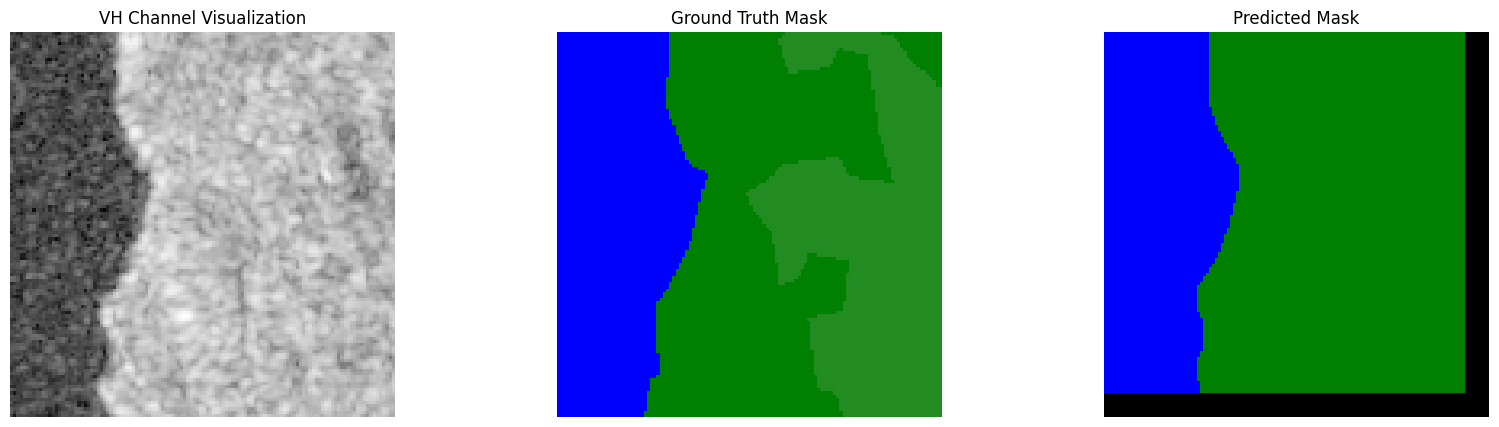

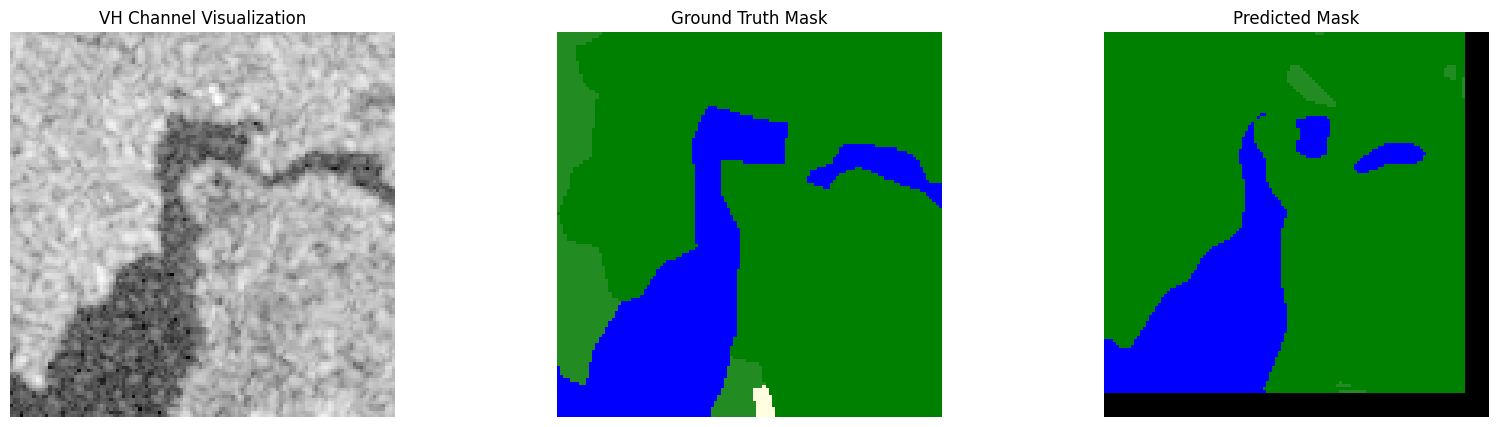

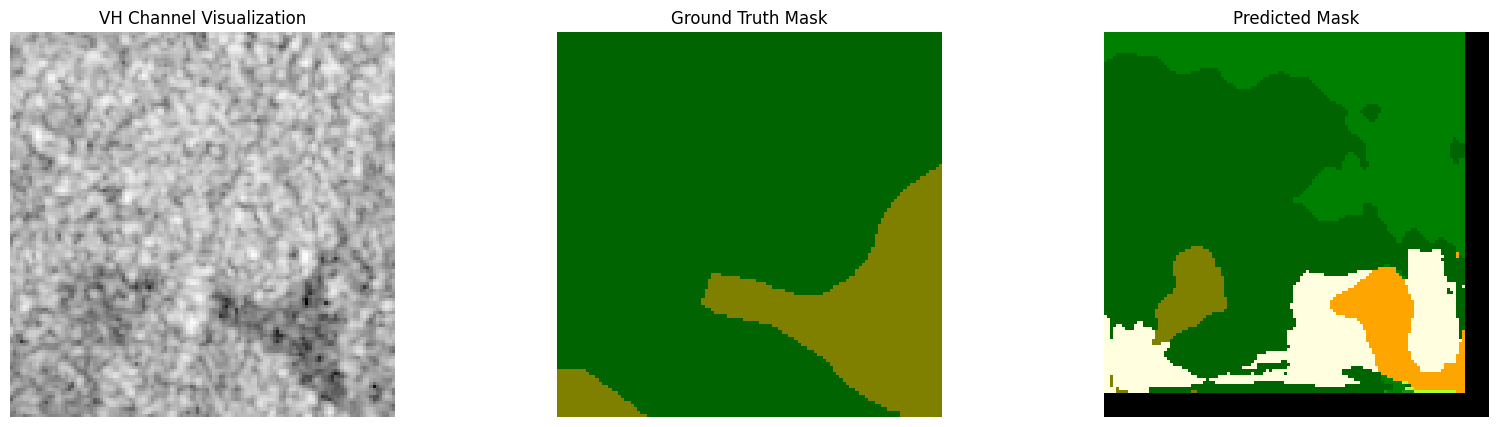

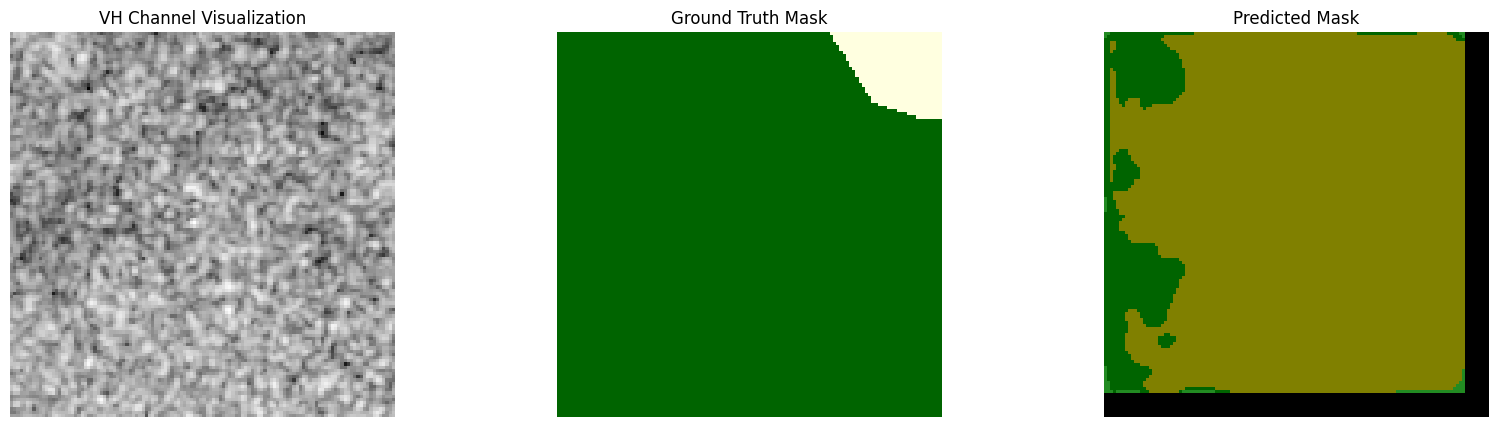

In [16]:
# Good
display_good_bad(model_display, lmdb_path, "S1B_IW_GRDH_1SDV_20180517T154802_35VNJ_55_62", "S2B_MSIL2A_20180515T094029_N9999_R036_T35VNJ_55_62_reference_map")
display_good_bad(model_display, lmdb_path, "S1A_IW_GRDH_1SDV_20180526T045642_34WFU_35_21", "S2A_MSIL2A_20180526T100031_N9999_R122_T34WFU_35_21_reference_map")

# Bad ? 
display_good_bad(model_display, lmdb_path, "S1B_IW_GRDH_1SDV_20180515T063421_29SNC_25_84", "S2B_MSIL2A_20180515T112109_N9999_R037_T29SNC_25_84_reference_map")
display_good_bad(model_display, lmdb_path, "S1B_IW_GRDH_1SDV_20180515T063421_29SNC_44_47", "S2B_MSIL2A_20180515T112109_N9999_R037_T29SNC_44_47_reference_map")

# PostHoc Explainability

Explainability via ImageRetrieval.

Ideas:
1. Validating for certain pixel batches in the output layer what their activations at the bottleneck are and then look for matches in training/val data that have very similar activations for these regions.
Constraint: Due to downsampling the regions in the bottleneck layer represent a much bigger size in the output layer. 
* How do I figure out how many "pixels" are represented in what X by X area per one number in the bottleneck layer? 
* How do I access the bottleneck layer?
* How do I store all (or a subset) of all training activations to quickly access them and still can match them to the reference image. Maybe append to the lmdb database as extra channel? 

## Store Train Activations

### Model initiieren

In [17]:
lmdb_path_experiment = '../data/activations_lmdb'
# lmdb_path_experiment_trial = 'activations_lmdb_trial'
lmdb_path = lmdb_path

In [18]:
# Load the model checkpoint
model_activations = load_from_checkpoint("../models/unet_epoch_20.pth")  # Modify this with your actual model loading function
model_activations.eval()  # Set to evaluation mode
model_activations.to(device)  # Move model to the correct device
print("Model loaded successfully!")

Model loaded successfully!


In [19]:
dummy_input = torch.randn(1, IMG_CHANNELS, 128, 128).to(device)
encoder_layer_shapes = get_encoder_sequential_layer_output_shapes(model_activations, dummy_input)

Layer 1: torch.Size([1, 256, 32, 32])
Layer 2: torch.Size([1, 512, 16, 16])
Layer 3: torch.Size([1, 1024, 8, 8])
Layer 4: torch.Size([1, 2048, 4, 4])


In [20]:
# Hook function to capture activations
activations_dict = {}

setup_hooks(model_activations, activations_dict)

## Aufbau von activation_dict:
```python
activations_dict = 
    {   
        "encoder.layer1 ": tensor([[[...]]]),
        "encoder.layer2 ": tensor([[[...]]]),
        "encoder.layer3 ": tensor([[[...]]]),
        "encoder.layer4 ": tensor([[[...]]]),
        ...
    }


In [21]:
print(keys_from_match(1000, matches))

('S1A_IW_GRDH_1SDV_20180206T153231_35VPK_72_35', 'S2B_MSIL2A_20180204T094159_N9999_R036_T35VPK_72_35_reference_map')


### [REMOVE `break` in Line 4 to run] Save training activations

In [22]:
# Loop through train_matches and compute activations for each image
env2 = lmdb.open(lmdb_path_experiment, map_size=4*10**11)  # Map size adjusted for your needs
for idx, match in tqdm(enumerate(train_matches), total=len(train_matches)):
    break # remove if you want to save new activations!
    image_key, reference_key = match
    
    # Load the corresponding image from the original LMDB database
    with lmdb.open(lmdb_path, readonly=True) as lmdb_env:
        with lmdb_env.begin() as txn:
            image_data = load(txn.get(image_key.encode()))
            image_bands = ["VH", "VV"]  # Sentinel 1 bands
            image_tensor = np.stack([image_data[band] for band in image_bands])
            
    image_tensor = torch.tensor(image_tensor, dtype=torch.float32).unsqueeze(0).to(device)
    image_tensor = pad_image(image_tensor, 128, 128)

    # Clear previous activations before each image
    activations_dict.clear()

    # Forward pass to get activations
    outputs = model_activations(image_tensor)  # Add batch dimension

    # Save activations for this image
    batch_activations = {k: v.cpu().numpy() for k, v in activations_dict.items()}
    with env2.begin(write=True) as txn:
        for layer_name, activation in batch_activations.items():
            # Create a unique key for each layer's activation
            layer_key = f"{image_key}_{layer_name}"
            txn.put(layer_key.encode(), activation.tobytes())

    # if (idx + 1) % 10000 == 0:
    #     print(f"Processed {idx + 1} images")
    
env2.close()


  0%|          | 0/237871 [00:00<?, ?it/s]


### Testing the loading of the activations

In [23]:
env2 = lmdb.open(lmdb_path_experiment, readonly=True, map_size=10**11)

# Example: Load activations for a specific image and layer
# index = 354
# image_reference, _ = keys_from_match(index, train_matches)
image_reference = "S1A_IW_GRDH_1SDV_20170808T043459_35ULA_19_15"
layer_name = 'encoder.layer1'   # Replace with the desired layer name

activation_tensor = load_activation(image_reference, layer_name, env = env2).to(device)

if activation_tensor is not None:
    print("Loaded activation shape:", activation_tensor.shape)
else: 
    print("Activation not found")
env2.close()

image, mask = get_image_and_mask_from_key(image_reference, lmdb_path = lmdb_path)
image = torch.tensor(image, dtype=torch.float32).to(device)
image = pad_image(image.unsqueeze(0), 128, 128)

# Pass the image through the model
output = model_activations(image)

# Get the activations for encoder.layer1
layer1_activations = activations_dict[layer_name]

# Compare layer1_activations with the loaded activation_tensor
if torch.allclose(layer1_activations, activation_tensor):
    print("Activations match successfully!")

Loaded activation shape: torch.Size([1, 256, 32, 32])
Activations match successfully!


## Experiment

In [24]:
from importlib import reload
reload(utils)
from ActivationPrototypes_SARSeg.thesis_utils import *

In [25]:
# Old matches
take_match = matches[:]
old_train_val_matches, old_test_matches = train_test_split(take_match, test_size=0.15, random_state=42)
old_train_matches, old_val_matches = train_test_split(old_train_val_matches, test_size=0.1764, random_state=42)

print(f"Train size: {len(old_train_matches)}, Val size: {len(old_val_matches)}, Test size: {len(old_test_matches)}")

# Create datasets
old_train_dataset = SARSegmentationDataset(lmdb_path, old_train_matches, transform=transformx)
old_val_dataset = SARSegmentationDataset(lmdb_path, old_val_matches, transform=None)
old_test_dataset = SARSegmentationDataset(lmdb_path, old_test_matches, transform=None)

# Create data loaders
batch_size = 16
old_train_loader = DataLoader(old_train_dataset, batch_size=batch_size, shuffle=True)
old_val_loader = DataLoader(old_val_dataset, batch_size=batch_size, shuffle=False)
old_test_loader = DataLoader(old_test_dataset, batch_size=batch_size, shuffle=False)

Train size: 139563, Val size: 29893, Test size: 29905
Opening LMDB environment ...
Opening LMDB environment ...
Opening LMDB environment ...


Top Left
Top N Results:  [(0.9366750954085049, 'S1B_IW_GRDH_1SDV_20171101T153951_35VNK_24_90'), (0.9330727870632128, 'S1B_IW_GRDH_1SDV_20170629T153202_35VPK_54_18'), (0.9330402758223173, 'S1B_IW_GRDH_1SDV_20170629T153202_35VPK_28_59'), (0.9283586344233357, 'S1B_IW_GRDH_1SDV_20170629T153202_35VPK_60_26'), (0.9210056896261333, 'S1A_IW_GRDH_1SDV_20180417T155012_34WFV_52_78')]


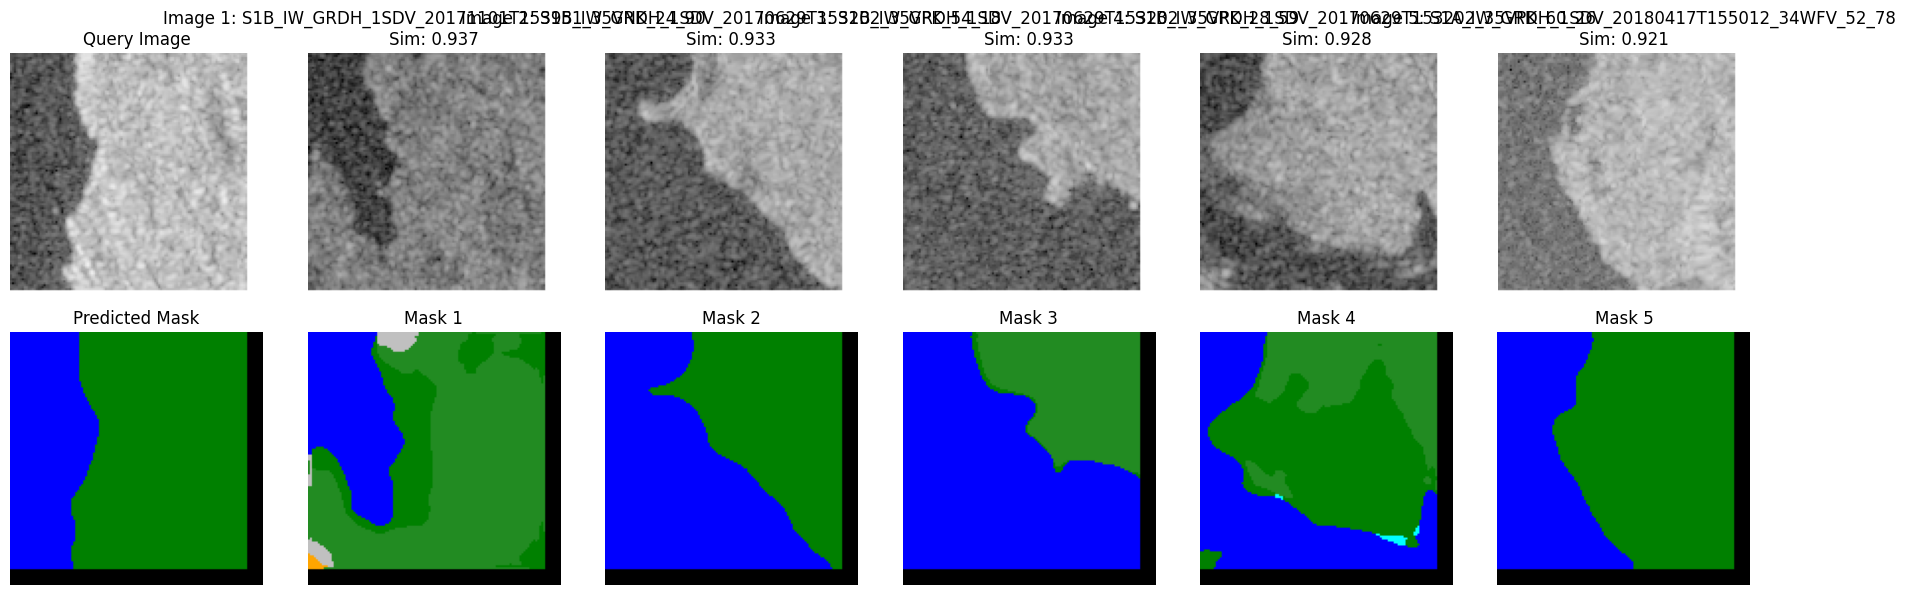

Bottom Left
Top N Results:  [(0.7759693097297251, 'S1B_IW_GRDH_1SDV_20180517T154802_35VNJ_51_61'), (0.7267533788973497, 'S1B_IW_GRDH_1SDV_20180517T154802_35VNJ_61_43'), (0.7032565000048498, 'S1B_IW_GRDH_1SDV_20180517T154802_35VNJ_78_87'), (0.6929527428113703, 'S1B_IW_GRDH_1SDV_20170709T043159_35VNL_50_74'), (0.6905216993291629, 'S1B_IW_GRDH_1SDV_20180517T154802_35VNJ_77_22')]


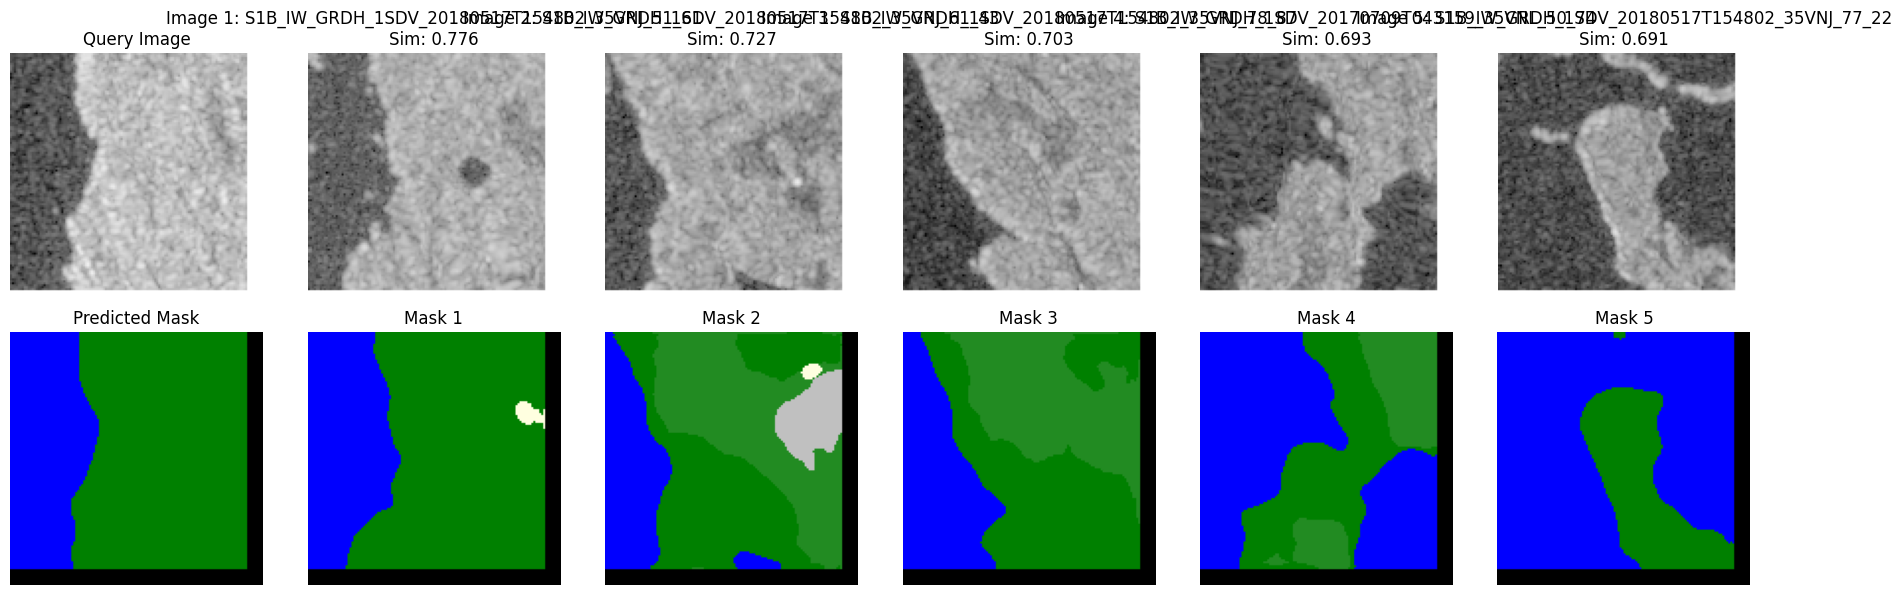

Top Right
Top N Results:  [(0.8179852004701798, 'S1B_IW_GRDH_1SDV_20180517T154802_35VNJ_51_61'), (0.7623165366961685, 'S1A_IW_GRDH_1SDV_20180415T160451_35VLG_84_18'), (0.7551509683972794, 'S1B_IW_GRDH_1SDV_20180517T154802_35VNJ_63_28'), (0.7366862430513136, 'S1B_IW_GRDH_1SDV_20170709T043159_35VNL_72_70'), (0.7308650194836495, 'S1B_IW_GRDH_1SDV_20170924T155419_35UMA_15_17')]


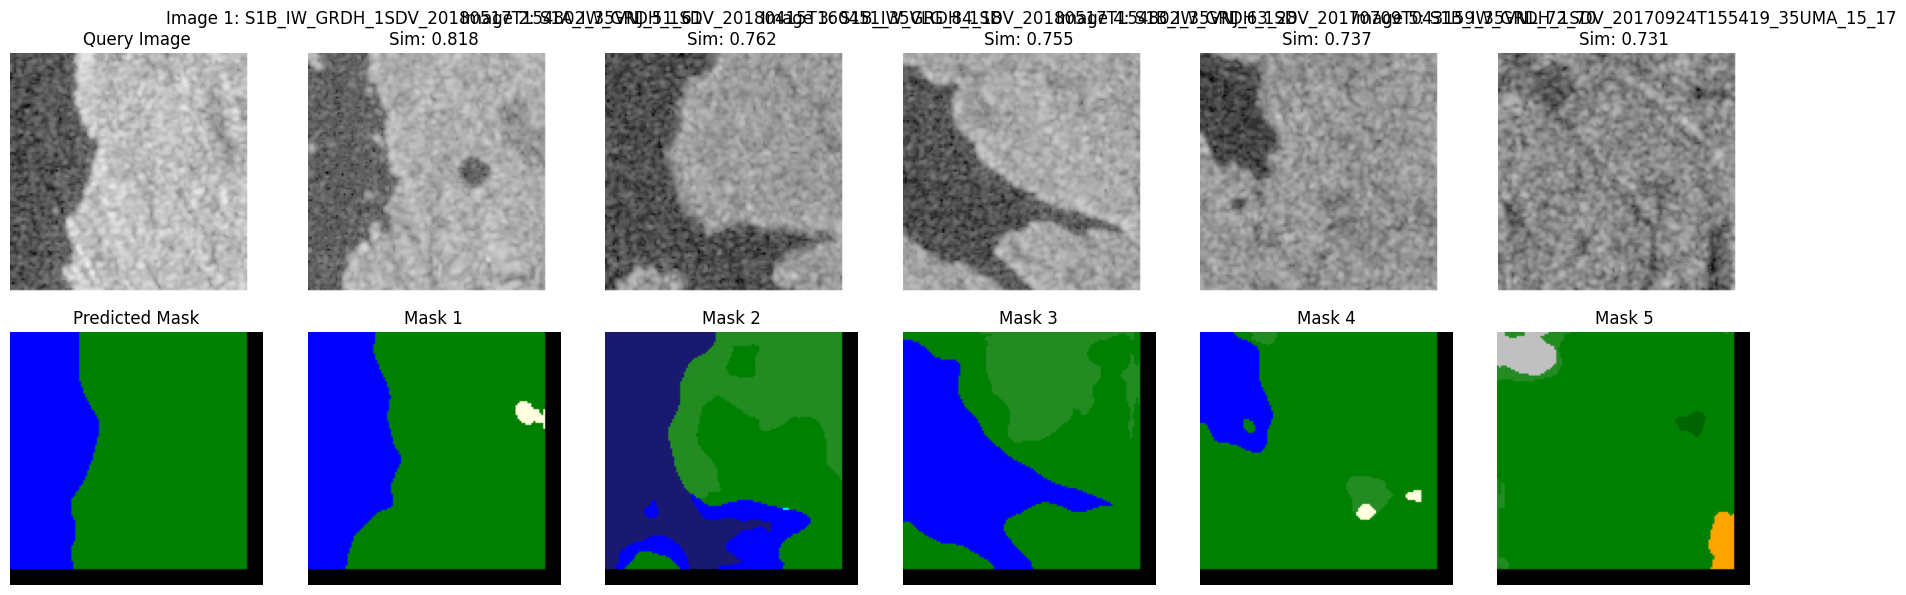

Bottom Right
Top N Results:  [(0.7922700977938583, 'S1B_IW_GRDH_1SDV_20170612T165809_33UUP_32_57'), (0.7758779215156225, 'S1B_IW_GRDH_1SDV_20180524T154016_35VNL_34_57'), (0.7634327285289827, 'S1B_IW_GRDH_1SDV_20180517T154802_35VNJ_49_29'), (0.7617856958174587, 'S1B_IW_GRDH_1SDV_20180524T154016_35VNL_35_89'), (0.756481013961811, 'S1B_IW_GRDH_1SDV_20180517T154802_35VNJ_80_61')]


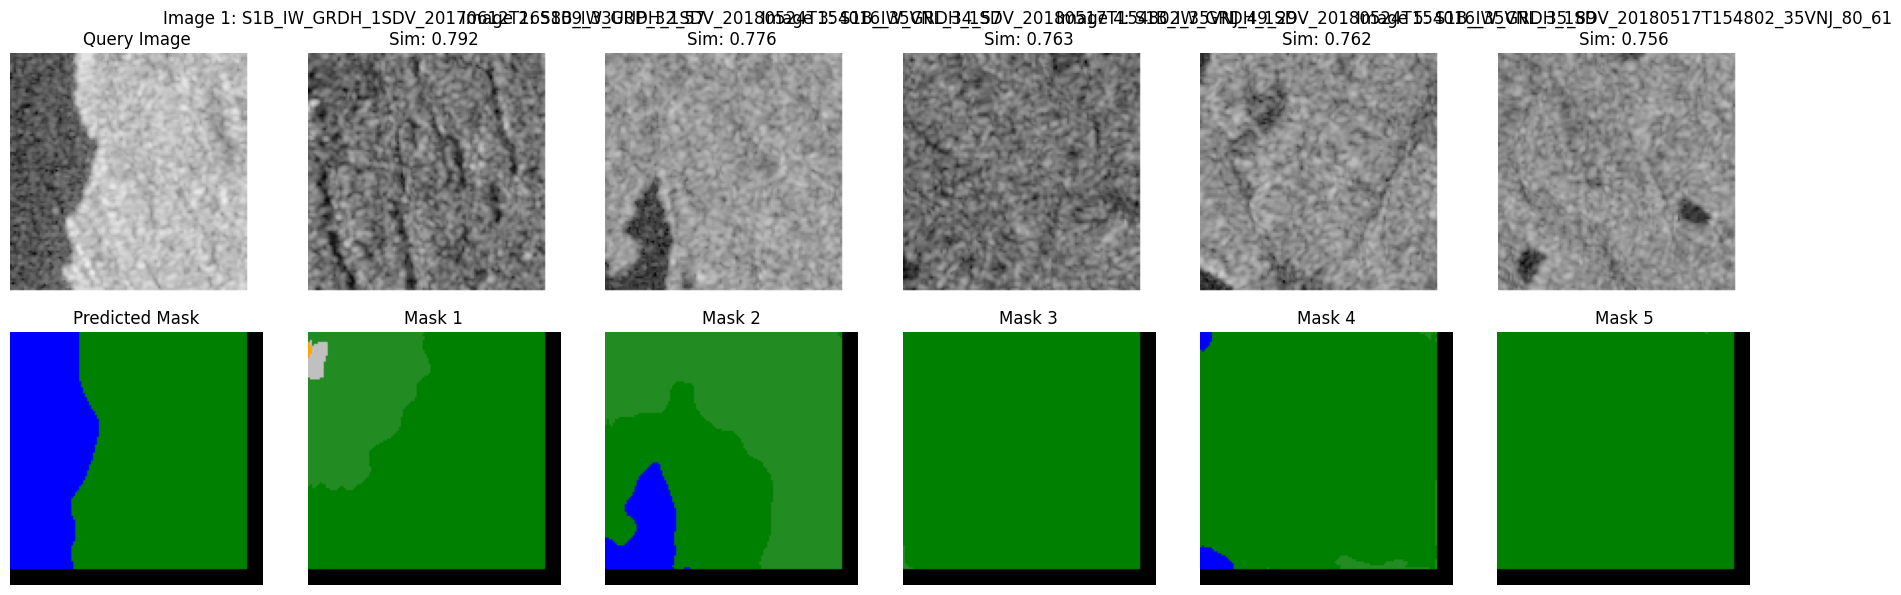

Full
Top N Results:  [(0.8217062943497107, 'S1A_IW_GRDH_1SDV_20180415T160451_35VLG_84_18'), (0.8066019014417285, 'S1A_IW_GRDH_1SDV_20180417T155012_34WFV_52_78'), (0.7890525614882858, 'S1B_IW_GRDH_1SDV_20171101T154016_35VNK_72_38'), (0.7867197989045726, 'S1B_IW_GRDH_1SDV_20180524T154016_35VNL_13_51'), (0.7855119388111436, 'S1B_IW_GRDH_1SDV_20180515T063421_29SNC_16_53')]


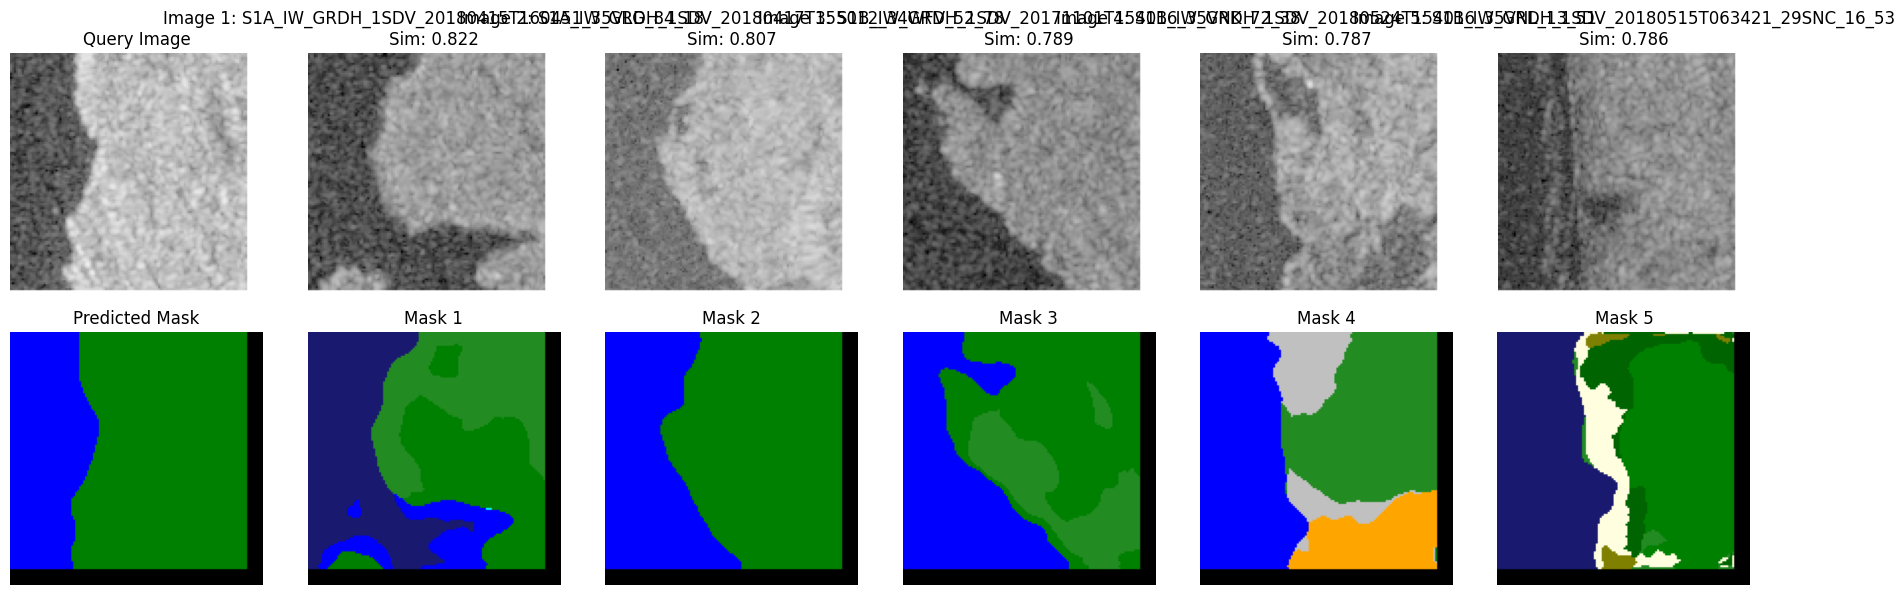

In [26]:
query_image_reference = 'S1B_IW_GRDH_1SDV_20180517T154802_35VNJ_55_62'
query_layer_name = 'encoder.layer4'  # Change to the layer you're analyzing

train_image_keys = []
for match in old_train_matches:
    train_image_key, _ = match
    train_image_keys.append(train_image_key)

trial_keys = train_image_keys[:10000]

region_coords_base = {
    "top_left": (0, 0, 64, 64),
    "top_right": (64, 0, 128, 64),
    "bottom_left": (0, 64, 64, 128),
    "bottom_right": (64, 64, 128, 128),
    "top_half": (0, 0, 128, 64),
    "bottom_half": (0, 64, 128, 128),
    "left_half": (0, 0, 64, 128),
    "right_half": (64, 0, 128, 128),
    "full": (0, 0, 128, 128),
} # Region coordinates for visualization
region_coords = region_coords_base["top_left"]

test_img, _ = get_image_and_mask_from_key(query_image_reference, lmdb_path = lmdb_path)
print("Top Left")
display_n_similar_images(test_img, activations_dict, query_layer_name, trial_keys, lmdb_path_experiment, lmdb_path, model_activations, region_coords=region_coords_base["top_left"])
print("Bottom Left")
display_n_similar_images(test_img, activations_dict, query_layer_name, trial_keys, lmdb_path_experiment, lmdb_path, model_activations, region_coords=region_coords_base["bottom_left"])
print("Top Right")
display_n_similar_images(test_img, activations_dict, query_layer_name, trial_keys, lmdb_path_experiment, lmdb_path, model_activations, region_coords=region_coords_base["top_right"])
print("Bottom Right")
display_n_similar_images(test_img, activations_dict, query_layer_name, trial_keys, lmdb_path_experiment, lmdb_path, model_activations, region_coords=region_coords_base["bottom_right"])
print("Full")
display_n_similar_images(test_img, activations_dict, query_layer_name, trial_keys, lmdb_path_experiment, lmdb_path, model_activations, region_coords=region_coords_base["full"])

# Thoughts and Trial

```
Stage	            Layer Type	                    Downsampling Factor
Input	            -	                            1× (Original size: 120×120)
Conv1	            7×7 Conv + Stride 2	            2× (Now: 60×60)
MaxPool	            3×3 Pool + Stride 2	            4× (Now: 30×30)
ResNet Block 1	    Convolutions	            4× (30×30)
ResNet Block 2	    Convolutions + Stride 2	    8× (Now: 15×15)
ResNet Block 3	    Convolutions + Stride 2	    16× (Now: 8×8)
ResNet Block 4	    Convolutions + Stride 2	    32× (Now: 4×4)
```

Unet expects symmetrical upsampling steps: 4 → 8 → 16 → 32 → 64

At the deepest layer (ResNet Block 4), the spatial resolution is reduced by a factor of 32.

This means for a 120×120 input, the output feature map at the deepest encoder layer is about (120/32) = 3.75, which is NOT an integer.

UNet’s decoder expects clean integer feature map sizes, so it forces an input size that is a multiple of 32.

Fix ideas:
1) Modify Encoder to avoid odd sizes
2) Manually Pad Encoder Output
3) Have a flexible Decoder that can handle odd sizes
4) use a different encoder that supports sizes natively and retrain from scratch without pretrained weights